# Explora aquí

Se recomienda utilizar este cuaderno con fines de exploración.

In [12]:
import os
from bs4 import BeautifulSoup
import requests
import time
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd



In [4]:
url = "https://en.wikipedia.org/wiki/List_of_most-streamed_songs_on_Spotify"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

print(response.status_code)

200


In [7]:
soup = BeautifulSoup(response.text, "html.parser")

tables = soup.find_all("table")

print(len(tables))

30


In [15]:
import io

df_list = pd.read_html(io.StringIO(response.text))

print(len(df_list))

30


In [16]:
for i, table in enumerate(df_list):
    print(i, table.shape)

0 (101, 6)
1 (13, 13)
2 (10, 9)
3 (2, 2)
4 (140, 6)
5 (18, 6)
6 (20, 7)
7 (21, 8)
8 (1, 2)
9 (9, 9)
10 (21, 9)
11 (1, 2)
12 (8, 9)
13 (18, 7)
14 (1, 2)
15 (5, 7)
16 (10, 7)
17 (11, 5)
18 (11, 6)
19 (11, 6)
20 (12, 6)
21 (11, 5)
22 (14, 6)
23 (21, 9)
24 (1, 2)
25 (6, 9)
26 (20, 9)
27 (1, 2)
28 (7, 9)
29 (5, 3)


In [17]:
df = df_list[0]
df.head()

,Rank,Song,Artist(s),Streams (billions),Release date,Ref.
0,1,"""Blinding Lights""",The Weeknd,5.406,29 November 2019,[1]
1,2,"""Shape of You""",Ed Sheeran,4.903,6 January 2017,[2]
2,3,"""Sweater Weather""",The Neighbourhood,4.591,3 December 2012,[3]
3,4,"""Starboy""",The Weeknd and Daft Punk,4.525,21 September 2016,[4]
4,5,"""As It Was""",Harry Styles,4.402,1 April 2022,[5]


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Rank                101 non-null    str  
 1   Song                101 non-null    str  
 2   Artist(s)           101 non-null    str  
 3   Streams (billions)  101 non-null    str  
 4   Release date        101 non-null    str  
 5   Ref.                98 non-null     str  
dtypes: str(6)
memory usage: 4.9 KB


In [19]:
df = df.drop(columns=["Ref."])
df.head()

,Rank,Song,Artist(s),Streams (billions),Release date
0,1,"""Blinding Lights""",The Weeknd,5.406,29 November 2019
1,2,"""Shape of You""",Ed Sheeran,4.903,6 January 2017
2,3,"""Sweater Weather""",The Neighbourhood,4.591,3 December 2012
3,4,"""Starboy""",The Weeknd and Daft Punk,4.525,21 September 2016
4,5,"""As It Was""",Harry Styles,4.402,1 April 2022


In [23]:
df["Streams (billions)"] = pd.to_numeric(
    df["Streams (billions)"],
    errors="coerce"
)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                101 non-null    str    
 1   Song                101 non-null    str    
 2   Artist(s)           101 non-null    str    
 3   Streams (billions)  100 non-null    float64
 4   Release date        101 non-null    str    
dtypes: float64(1), str(4)
memory usage: 4.1 KB


In [25]:
conn = sqlite3.connect("spotify_songs.db")

df.to_sql(
    "songs",
    conn,
    if_exists="replace",
    index=False
)

conn.commit()

print("Datos guardados correctamente en SQLite")

Datos guardados correctamente en SQLite


/tmp/ipykernel_6875/3917658444.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


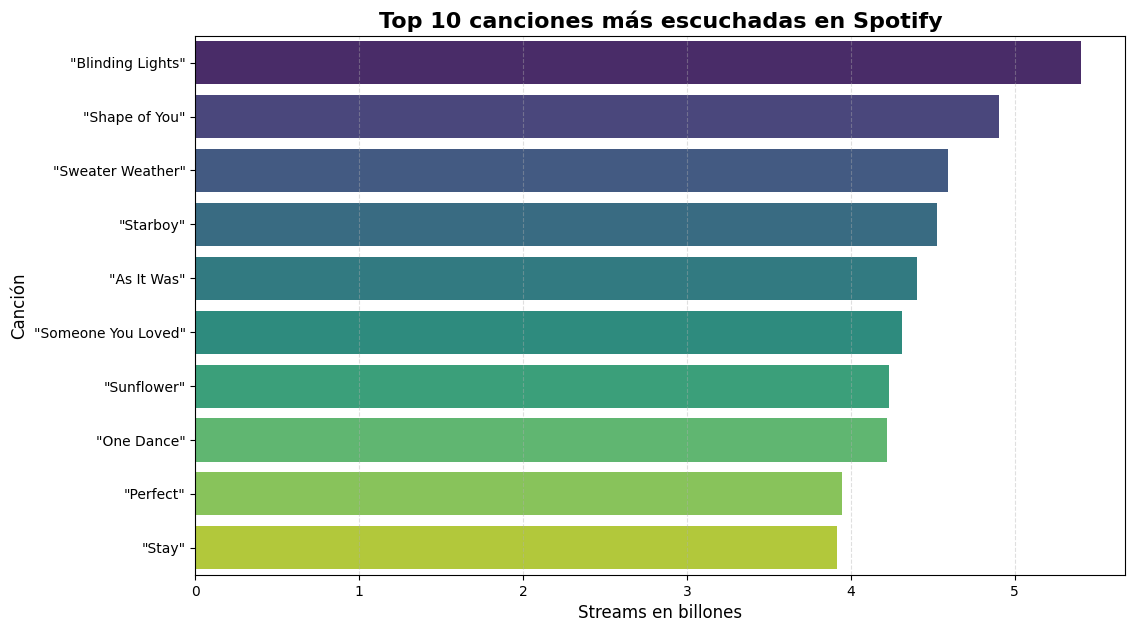

In [27]:
top_10 = df.sort_values("Streams (billions)", ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_10,
    x="Streams (billions)",
    y="Song",
    palette="viridis"
)

plt.title("Top 10 canciones más escuchadas en Spotify", fontsize=16, fontweight="bold")
plt.xlabel("Streams en billones", fontsize=12)
plt.ylabel("Canción", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.show()

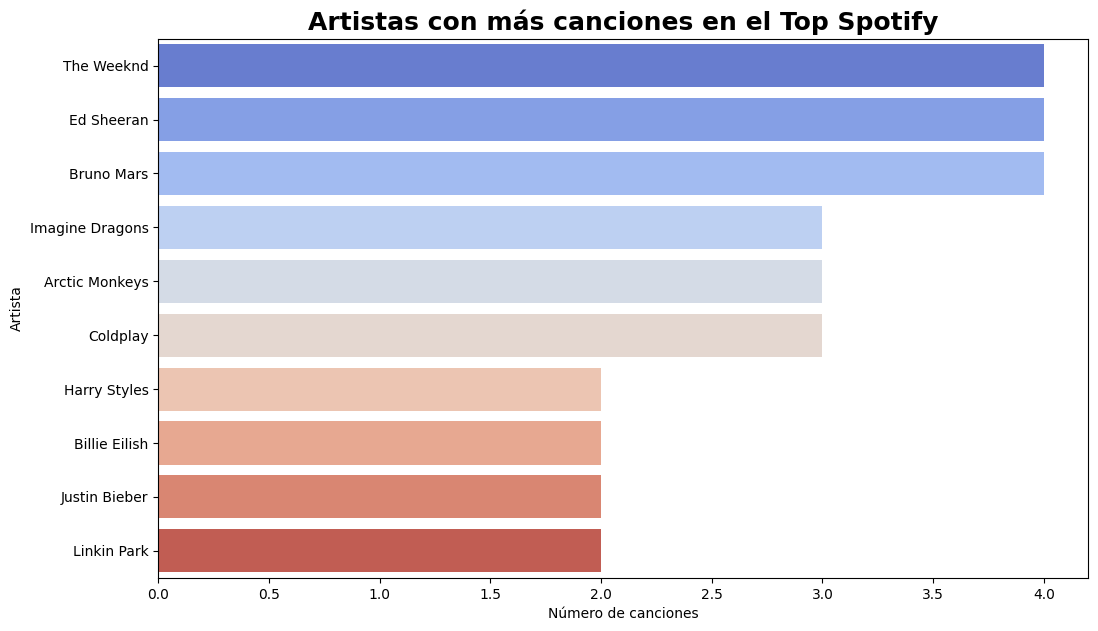

In [28]:
top_artists = df["Artist(s)"].value_counts().head(10)

plt.figure(figsize=(12,7))

sns.barplot(
    x=top_artists.values,
    y=top_artists.index,
    hue=top_artists.index,
    palette="coolwarm",
    legend=False
)

plt.title(
    "Artistas con más canciones en el Top Spotify",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Número de canciones")
plt.ylabel("Artista")

plt.show()

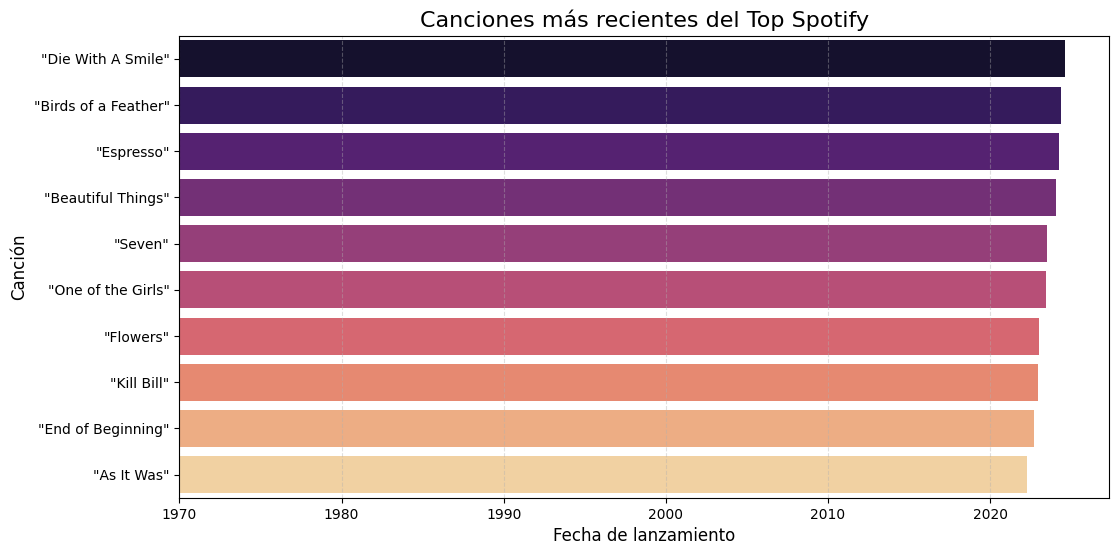

In [30]:
df["Release date"] = pd.to_datetime(df["Release date"], errors="coerce")

recent_songs = df.sort_values("Release date", ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=recent_songs,
    x="Release date",
    y="Song",
    hue="Song",
    palette="magma",
    legend=False
)

plt.title("Canciones más recientes del Top Spotify", fontsize=16)
plt.xlabel("Fecha de lanzamiento", fontsize=12)
plt.ylabel("Canción", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.show()